# Data convertion text file to csv

In [62]:
import csv

def convert_txt_to_csv(txt_path, csv_path):
    with open(txt_path, 'r') as infile, open(csv_path, 'w', newline='') as outfile:
        reader = csv.reader(infile, delimiter=';')  # Adjust delimiter if needed
        writer = csv.writer(outfile)
        
        for row in reader:
            writer.writerow(row)

    print(f"✅ File converted successfully: {csv_path}")

# File paths
txt_file = r"E:/Guvi Projects/project 3 electric/code/household_power_consumption.txt"
csv_file = r"E:/Guvi Projects/project 3 electric/code/household_power_consumption.csv"

convert_txt_to_csv(txt_file, csv_file)


✅ File converted successfully: E:/Guvi Projects/project 3 electric/code/household_power_consumption.csv


# Data Understanding and Exploration:
Load and explore the dataset to understand its structure, variables, and quality.
Perform exploratory data analysis (EDA) to identify patterns, correlations, and outliers.


In [76]:
import pandas as pd

# Load the CSV file into a DataFrame
# df = pd.read_csv("E:/Guvi Projects/project 3 electric/code/household_power_consumption.csv", sep=';', low_memory=False)
df = pd.read_csv("E:/Guvi Projects/project 3 electric/code/household_power_consumption.txt", sep=';', header=0)
# Display the first few rows of the DataFrame
print(df.head())
# Display the shape of the DataFrame
print("Shape of the DataFrame:", df.shape)
# Display the column names
print("Column names:", df.columns.tolist())
# Display the data types of each column
print("Data types of each column:")

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  
Shape of the DataFrame: (2075259, 9)
Column names: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'G

C:\Users\Arjun\AppData\Local\Temp\ipykernel_11688\3274388758.py:5: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("E:/Guvi Projects/project 3 electric/code/household_power_consumption.txt", sep=';', header=0)


In [77]:
print(df.columns)
print(df.describe(include='all'))
print(df.info())


Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')
             Date      Time Global_active_power Global_reactive_power  \
count     2075259   2075259             2075259               2075259   
unique       1442      1440                6534                   896   
top     6/12/2008  17:24:00                   ?                 0.000   
freq         1440      1442               25979                472786   
mean          NaN       NaN                 NaN                   NaN   
std           NaN       NaN                 NaN                   NaN   
min           NaN       NaN                 NaN                   NaN   
25%           NaN       NaN                 NaN                   NaN   
50%           NaN       NaN                 NaN                   NaN   
75%           NaN       NaN                 NaN                   NaN   
max 

## Converting data types 

In [78]:
import pandas as pd

# Strip column names of extra spaces
df.columns = df.columns.str.strip()

# Combine 'Date' and 'Time' into a new 'DateTime' column
df["DateTime"] = pd.to_datetime(df["Date"] + ' ' + df["Time"], format="%d/%m/%Y %H:%M:%S", errors='coerce')

# Drop the old Date and Time columns if not needed
df.drop(columns=["Date", "Time"], inplace=True)

# Convert numeric columns from object to float
cols_to_convert = df.columns.difference(["DateTime"])  # Exclude DateTime from conversion
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Show the updated data types
print(df.dtypes)


Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
DateTime                 datetime64[ns]
dtype: object


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


## Handling Missing Values

In [80]:
print(df.isnull().sum())


Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
DateTime                     0
dtype: int64


In [81]:
df.dropna(inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 140.7 MB


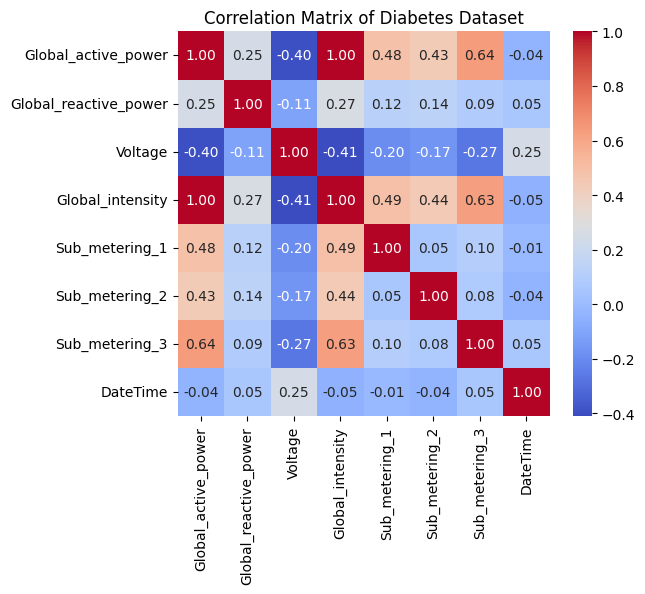

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Diabetes Dataset')
plt.show()

## Outliers

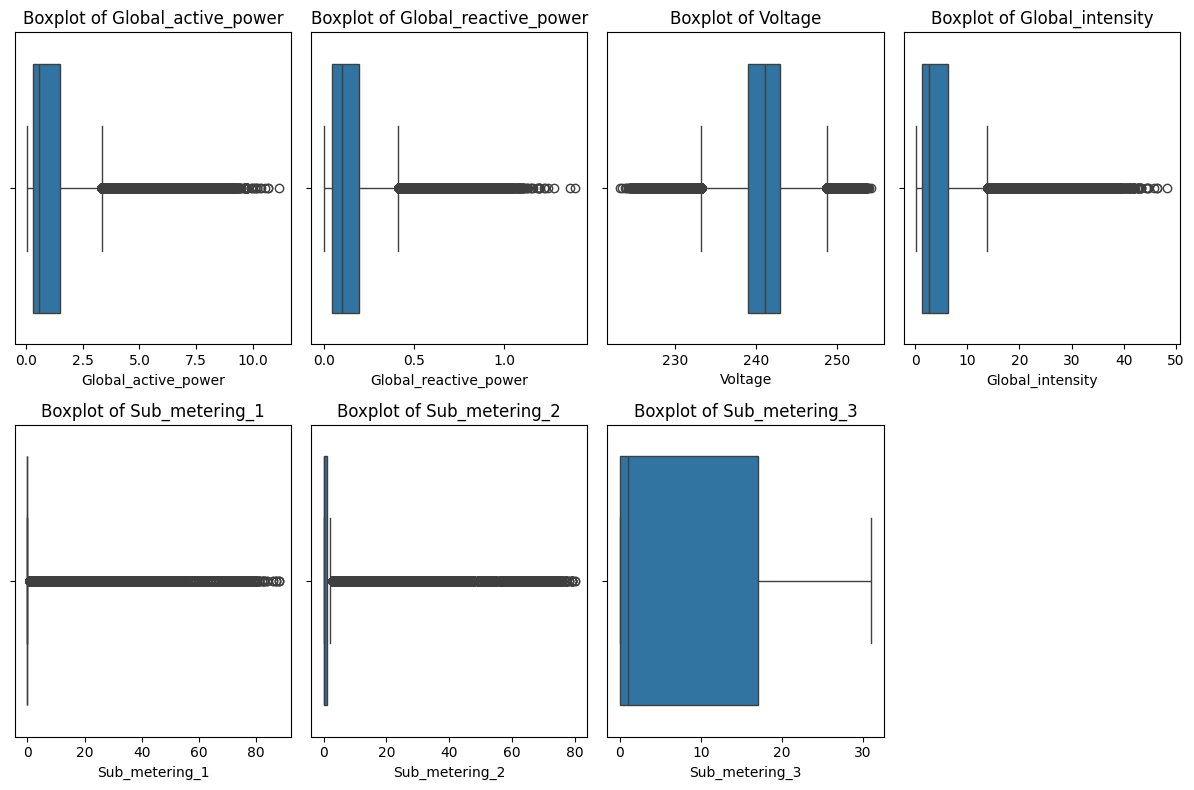

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot boxplots for numerical columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 4, i)  # Adjust grid size (2 rows, 4 columns)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [84]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define the range for normal values
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Check which values are outliers
outliers = (df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)
print(outliers.sum())


Global_active_power       94907
Global_reactive_power     40420
Voltage                   51067
Global_intensity         100961
Sub_metering_1           169105
Sub_metering_2            77151
Sub_metering_3                0
dtype: int64


In [85]:
from scipy.stats import zscore

z_scores = zscore(df[numeric_cols])
outliers_zscore = (z_scores > 3) | (z_scores < -3)

print((outliers_zscore).sum())  # Count of outliers per column


Global_active_power      36160
Global_reactive_power    24480
Voltage                  12759
Global_intensity         37434
Sub_metering_1           56097
Sub_metering_2           50993
Sub_metering_3               0
dtype: int64


In [86]:
# Calculate the IQR for each numerical column
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove rows where any column has a value outside the bounds
df = df[~((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)]

# Show the cleaned DataFrame info
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 1739167 entries, 16 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 119.4 MB
None


# Data Preprocessing

In [ ]:
# Extract additional features from DateTime
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["Minute"] = df["DateTime"].dt.minute
df["Weekday"] = df["DateTime"].dt.weekday  # Monday=0, Sunday=6
df["DayOfYear"] = df["DateTime"].dt.dayofyear

In [89]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,Year,Month,Day,Hour,Minute,Weekday,DayOfYear
16,3.270,0.152,236.73,13.8,0.0,0.0,17.0,2006-12-16 17:40:00,2006,12,16,17,40,5,350
18,3.266,0.000,237.13,13.8,0.0,0.0,18.0,2006-12-16 17:42:00,2006,12,16,17,42,5,350
25,3.248,0.000,236.66,13.6,0.0,0.0,17.0,2006-12-16 17:49:00,2006,12,16,17,49,5,350
26,3.236,0.000,235.84,13.6,0.0,0.0,17.0,2006-12-16 17:50:00,2006,12,16,17,50,5,350
27,3.228,0.000,235.60,13.6,0.0,0.0,17.0,2006-12-16 17:51:00,2006,12,16,17,51,5,350


## Create Additional Features

In [ ]:
df['Daily_Avg_Global_active_power'] = df.groupby('DateTime')['Global_active_power'].transform('mean')



Peak hour for power consumption: 21


<Axes: title={'center': 'Monthly Average of Global Active Power'}>

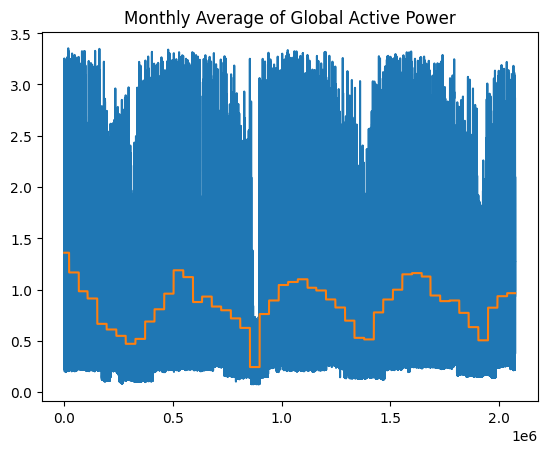

In [93]:
peak_hour = df.groupby('Hour')['Global_active_power'].mean().idxmax()  # Hour with highest average power consumption
print(f"Peak hour for power consumption: {peak_hour}")

df['7_day_avg_Global_active_power'] = df['Global_active_power'].rolling(window=7).mean()
df['7_day_avg_Global_active_power'].plot(title='7-Day Rolling Average of Global Active Power')

df['Monthly_Avg_Global_active_power'] = df.groupby(['Year', 'Month'])['Global_active_power'].transform('mean')
df['Monthly_Avg_Global_active_power'].plot(title='Monthly Average of Global Active Power')

## Normalize or Scale the Data

In [94]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_columns = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
df[scaled_columns] = scaler.fit_transform(df[scaled_columns])


# Identify Relevant Features

In [ ]:
#  Power Usage Patterns
# Total consumption from all sub meters
df['Total_Sub_Metering'] = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']

# Difference between global active power and sub metering (may hint at other consumption)
df['Unaccounted_Power'] = df['Global_active_power'] * 1000 / 60 - df['Total_Sub_Metering']  # convert to watt-minutes


In [ ]:
# Lag Features & Rolling Averages
# Previous hour's consumption
df['Lag1'] = df['Global_active_power'].shift(1)

# 3-hour rolling mean
df['RollingMean_3'] = df['Global_active_power'].rolling(window=3).mean()

# 24-hour rolling mean
df['RollingMean_24'] = df['Global_active_power'].rolling(window=24).mean()


In [99]:
# Encoding Categorical Time Features
df = pd.get_dummies(df, columns=['Weekday', 'Month'], drop_first=True)


In [100]:
df.to_csv("cleaned_household_power_consumption.csv", index=False)